In [1]:
# Importação das bibliotecas necessárias
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd

2026-05-31 17:20:41.847222: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 17:20:46.289132: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 17:20:48.070142: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780248051.082441   11271 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780248051.881270   11271 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780248058.421899   11271 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [11]:
## carregamento
df=pd.read_csv('../data/diabetes_dataset.csv')

In [12]:
# 5% para teste
df_teste = df.sample(frac=0.05)

In [13]:
df.head(2)

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0


In [14]:
## Remove coluna "year"
df.drop('year',axis=1,inplace=True)

## Encoding da coluna "gender"
df=pd.get_dummies(df,columns=['gender'],drop_first=True)
df['gender_Male']=df['gender_Male'].astype(int)
df['gender_Other']=df['gender_Other'].astype(int)
#df['smoking_history'].unique()

In [15]:
df.head()

,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other
0,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,0,0
1,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,0,0
2,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,1,0
3,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,1,0
4,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,0,0


In [16]:
# Seleciona quais serão as colunas usadas (X)
X=df[['age','hypertension','hbA1c_level','bmi','heart_disease','blood_glucose_level']]

# Separa a coluna que representa a classe
y=df['diabetes']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=101)

In [17]:
## Scalling
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.fit_transform(X_test)

#### Arquitetura da rede utilizada:
- Multilayer Perceptron
- 3 camadas escondidas:
    - Camada escondida 1: 64 neurônios com função de ativação relu;
    - Camada escondida 1: 32 neurônios com função de ativação relu;
    - Camada escondida 1: 16 neurônios com função de ativação relu;
- Camada de saída: 1 neurônio com função de ativação Sigmiod. Nossa resposta será a probabilidade do paciente possuir ou não diabetes
- Algoritmo de otimização: "Stochastig Gradient Descent"

In [18]:
## Training

model = Sequential() # Feedforward
model.add(Dense(units=64, activation="relu")) # Escondida
model.add(Dense(units=32, activation="relu")) # Escondida
model.add(Dense(units=16, activation="relu")) # Escondida
model.add(Dense(units=1, activation="sigmoid")) # Neurônio de saída com função de ativação Sigmoid

model.compile(loss="binary_crossentropy", optimizer="SGD") # Backpropagation

2026-05-31 17:34:43.592985: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [19]:
# EarlyStopping. Treinamento para se o erro não diminuir em X épocas
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor="val_loss", mode="min", patience=20)

In [20]:
model.fit(x=X_train, 
          y=y_train, 
          epochs=60, 
          validation_data=(X_test, y_test),
          callbacks=[early_stop])

Epoch 1/60


2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.2625 - val_loss: 0.1181
Epoch 2/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1172 - val_loss: 0.1148
Epoch 3/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1107 - val_loss: 0.1132
Epoch 4/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1129 - val_loss: 0.1096
Epoch 5/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1089 - val_loss: 0.1078
Epoch 6/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1093 - val_loss: 0.1069
Epoch 7/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1033 - val_loss: 0.1051
Epoch 8/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1011 - val_loss: 0.1038
Epoch 9/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1044 - val_loss: 0.1028
Epoch 10/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0996 - val_loss: 0.1022
Epoch 11/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1017 - val_loss: 0.1013
Epoch 12/60
2188/2188 ━━━━━━━━━━━━━━━━━━━

<Axes: >

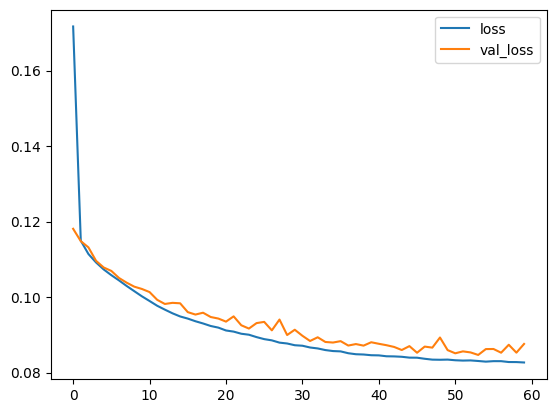

In [21]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

In [22]:
preds = (model.predict(X_test)).astype("int32")

123/938 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step

938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 815us/step


In [23]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96     27422
           1       1.00      0.18      0.30      2578

    accuracy                           0.93     30000
   macro avg       0.96      0.59      0.63     30000
weighted avg       0.93      0.93      0.91     30000



Exemplo de registro:
*  age : 40
*  hypertension : 1
*  hbA1c_leve : 6.5
*  bmi : 28.9
*  heart_disease : 0
*  blood_glucose_level : 166

In [24]:
## Predicting

prediction=(model.predict(scale.transform(np.array([[40,1,6.5,28.9,0,166]])))).astype('int32')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


/workspaces/ml-supervised-dev/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [25]:
prediction

array([[0]], dtype=int32)

---

#### Salvando os pesos da rede após o treinamento e validação

In [27]:
model.save_weights("pesos_modelo_diabetes.weights.h5")

---

#### Carregando os pesos

Após salvar os pesos, podemos carregá-los em uma rede com arquitetura já construída. Vamos usa o mesmo modelo que foi criado anteriormente.

In [29]:
model.load_weights("pesos_modelo_diabetes.weights.h5")

Após isso é possível fazer a execução do `.predict` nos dados. Mas é importante que esses dados estejam no formato usado durante o treinamento da rede.